In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 100)

sns.set_theme(style="whitegrid")

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

INPUT_FILE = PROJECT_ROOT / "data" / "raw" / "inpatient.csv"

print("Project root:", PROJECT_ROOT)
print("Input file:", INPUT_FILE)
print("File exists:", INPUT_FILE.exists())
print("File size (MB):", round(INPUT_FILE.stat().st_size / 1024**2, 2))

Project root: d:\projects\Medicare Claims Analytics
Input file: d:\projects\Medicare Claims Analytics\data\raw\inpatient.csv
File exists: True
File size (MB): 33.89


In [3]:
inpatient = pd.read_csv(
    INPUT_FILE,
    sep="|",
    dtype="string",
    low_memory=False,
    na_values=["", " "],
)

inpatient.shape

(58066, 197)

In [4]:
overview = pd.DataFrame({
    "metric": [
        "Physical rows",
        "Columns",
        "Unique beneficiaries",
        "Unique claims",
    ],
    "value": [
        len(inpatient),
        inpatient.shape[1],
        inpatient["BENE_ID"].nunique(dropna=True),
        inpatient["CLM_ID"].nunique(dropna=True),
    ],
})

overview


,metric,value
0,Physical rows,58066
1,Columns,197
2,Unique beneficiaries,5699
3,Unique claims,20867


In [5]:
grain_check = pd.DataFrame({
    "check": [
        "Physical rows",
        "Unique CLM_ID",
        "Repeated CLM_ID rows",
        "Missing CLM_ID",
        "Missing CLM_LINE_NUM",
        "Duplicate CLM_ID + CLM_LINE_NUM",
    ],
    "result": [
        len(inpatient),
        inpatient["CLM_ID"].nunique(dropna=True),
        inpatient["CLM_ID"].duplicated().sum(),
        inpatient["CLM_ID"].isna().sum(),
        inpatient["CLM_LINE_NUM"].isna().sum(),
        inpatient.duplicated(
            subset=["CLM_ID", "CLM_LINE_NUM"]
        ).sum(),
    ],
})

grain_check

,check,result
0,Physical rows,58066
1,Unique CLM_ID,20867
2,Repeated CLM_ID rows,37199
3,Missing CLM_ID,0
4,Missing CLM_LINE_NUM,0
5,Duplicate CLM_ID + CLM_LINE_NUM,0


,lines_per_claim
count,20867.000000
mean,2.782671
std,2.840832
min,1.000000
25%,1.000000
50%,1.000000
75%,4.000000
max,46.000000


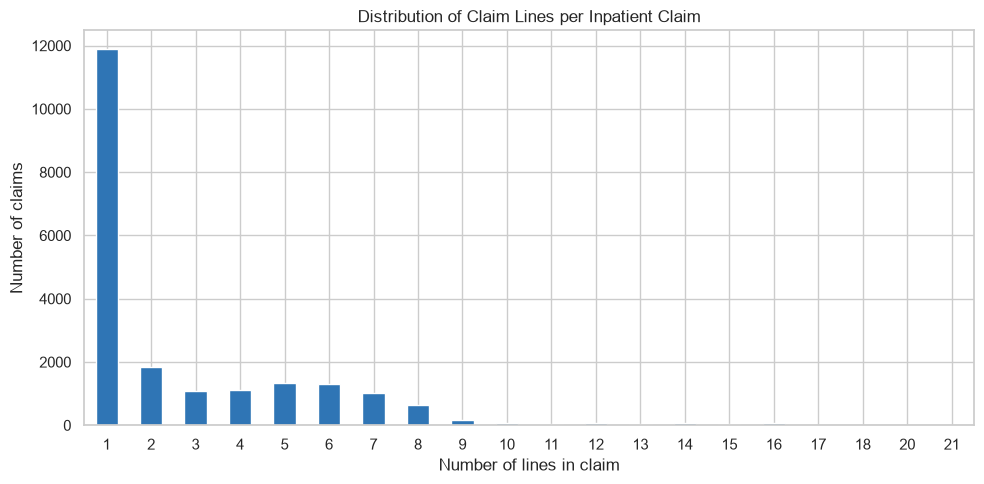

In [6]:
lines_per_claim = inpatient.groupby("CLM_ID").size()

display(lines_per_claim.describe().to_frame("lines_per_claim"))

line_distribution = (
    lines_per_claim
    .value_counts()
    .sort_index()
    .head(20)
)

ax = line_distribution.plot(
    kind="bar",
    figsize=(10, 5),
    color="#2F75B5",
)

ax.set_title("Distribution of Claim Lines per Inpatient Claim")
ax.set_xlabel("Number of lines in claim")
ax.set_ylabel("Number of claims")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
claim_level_columns = [
    "BENE_ID",
    "CLM_FROM_DT",
    "CLM_THRU_DT",
    "CLM_ADMSN_DT",
    "NCH_BENE_DSCHRG_DT",
    "PRVDR_NUM",
    "CLM_PMT_AMT",
    "CLM_TOT_CHRG_AMT",
    "CLM_DRG_CD",
    "PRNCPAL_DGNS_CD",
]

claim_variation = (
    inpatient
    .groupby("CLM_ID")[claim_level_columns]
    .nunique(dropna=False)
)

inconsistent_claim_fields = (
    claim_variation.gt(1)
    .sum()
    .sort_values(ascending=False)
    .rename("claims_with_multiple_values")
    .to_frame()
)

inconsistent_claim_fields

,claims_with_multiple_values
BENE_ID,0
CLM_FROM_DT,0
CLM_THRU_DT,0
CLM_ADMSN_DT,0
NCH_BENE_DSCHRG_DT,0
PRVDR_NUM,0
CLM_PMT_AMT,0
CLM_TOT_CHRG_AMT,0
CLM_DRG_CD,0
PRNCPAL_DGNS_CD,0


In [8]:
key_check = pd.DataFrame({
    "check": [
        "Missing CLM_ID",
        "Missing CLM_LINE_NUM",
        "Duplicate CLM_ID + CLM_LINE_NUM",
        "Completely duplicated rows",
    ],
    "count": [
        inpatient["CLM_ID"].isna().sum(),
        inpatient["CLM_LINE_NUM"].isna().sum(),
        inpatient.duplicated(
            subset=["CLM_ID", "CLM_LINE_NUM"]
        ).sum(),
        inpatient.duplicated().sum(),
    ],
})

key_check

,check,count
0,Missing CLM_ID,0
1,Missing CLM_LINE_NUM,0
2,Duplicate CLM_ID + CLM_LINE_NUM,0
3,Completely duplicated rows,0


In [9]:
variation_counts = (
    inpatient
    .groupby("CLM_ID", sort=False)
    .nunique(dropna=False)
    .gt(1)
    .sum()
    .sort_values(ascending=False)
)

varying_columns = (
    variation_counts[variation_counts > 0]
    .rename("claims_with_multiple_values")
    .to_frame()
)

varying_columns["percent_of_claims"] = (
    varying_columns["claims_with_multiple_values"]
    / inpatient["CLM_ID"].nunique()
    * 100
).round(2)

varying_columns

,claims_with_multiple_values,percent_of_claims
CLM_LINE_NUM,8982,43.04
HCPCS_CD,8825,42.29
REV_CNTR_DDCTBL_COINSRNC_CD,973,4.66


In [10]:
line_attribute_columns = [
    "CLM_LINE_NUM",
    "REV_CNTR",
    "HCPCS_CD",
    "REV_CNTR_DDCTBL_COINSRNC_CD",
]

claim_columns = [
    column
    for column in inpatient.columns
    if column not in line_attribute_columns
]

inpatient_claim = (
    inpatient[claim_columns]
    .drop_duplicates(subset=["CLM_ID"])
    .reset_index(drop=True)
)

inpatient_claim_line = (
    inpatient[
        ["CLM_ID"] + line_attribute_columns
    ]
    .copy()
    .reset_index(drop=True)
)

In [11]:
display(inpatient_claim.head())
display(inpatient_claim_line.head(10))


,BENE_ID,CLM_ID,NCH_NEAR_LINE_REC_IDENT_CD,NCH_CLM_TYPE_CD,CLM_FROM_DT,CLM_THRU_DT,NCH_WKLY_PROC_DT,FI_CLM_PROC_DT,CLAIM_QUERY_CODE,PRVDR_NUM,CLM_FAC_TYPE_CD,CLM_SRVC_CLSFCTN_TYPE_CD,CLM_FREQ_CD,FI_NUM,CLM_MDCR_NON_PMT_RSN_CD,CLM_PMT_AMT,NCH_PRMRY_PYR_CLM_PD_AMT,NCH_PRMRY_PYR_CD,FI_CLM_ACTN_CD,PRVDR_STATE_CD,ORG_NPI_NUM,AT_PHYSN_UPIN,AT_PHYSN_NPI,OP_PHYSN_UPIN,OP_PHYSN_NPI,...,ICD_PRCDR_CD15,PRCDR_DT15,ICD_PRCDR_CD16,PRCDR_DT16,ICD_PRCDR_CD17,PRCDR_DT17,ICD_PRCDR_CD18,PRCDR_DT18,ICD_PRCDR_CD19,PRCDR_DT19,ICD_PRCDR_CD20,PRCDR_DT20,ICD_PRCDR_CD21,PRCDR_DT21,ICD_PRCDR_CD22,PRCDR_DT22,ICD_PRCDR_CD23,PRCDR_DT23,ICD_PRCDR_CD24,PRCDR_DT24,ICD_PRCDR_CD25,PRCDR_DT25,IME_OP_CLM_VAL_AMT,DSH_OP_CLM_VAL_AMT,CLM_UNCOMPD_CARE_PMT_AMT
0,-10000010254618,-10000930037831,V,60,25-Mar-2015,25-Mar-2015,27-Mar-2015,<NA>,3,011500,1,1,1,<NA>,<NA>,96.65,0,<NA>,<NA>,01,1578657367,<NA>,9999870899,<NA>,9999870899,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,0,<NA>
1,-10000010254653,-10000930038030,V,60,24-Sep-2015,24-Sep-2015,25-Sep-2015,<NA>,3,017129,1,1,1,<NA>,<NA>,6311.88,6276.88,<NA>,<NA>,01,1770717738,<NA>,9999877191,<NA>,9999877191,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,0,<NA>
2,-10000010254653,-10000930038031,V,60,09-May-2017,10-May-2017,12-May-2017,<NA>,3,010052,1,1,1,<NA>,<NA>,8545.72,0,<NA>,<NA>,01,1598783904,<NA>,9999995399,<NA>,9999995399,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,0,<NA>
3,-10000010254656,-10000930038162,V,60,14-Jan-2017,14-Jan-2017,20-Jan-2017,<NA>,3,015455,1,1,1,<NA>,<NA>,1014.85,979.85,<NA>,<NA>,01,1033215660,<NA>,9999856690,<NA>,9999856690,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,0,<NA>
4,-10000010254656,-10000930038163,V,60,17-Mar-2018,17-Mar-2018,23-Mar-2018,<NA>,3,015455,1,1,1,<NA>,<NA>,9911.41,9876.41,<NA>,<NA>,01,1033215660,<NA>,9999856690,<NA>,9999856690,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,0,<NA>


,CLM_ID,CLM_LINE_NUM,REV_CNTR,HCPCS_CD,REV_CNTR_DDCTBL_COINSRNC_CD
0,-10000930037831,1,0450,99221,<NA>
1,-10000930038030,1,0450,99221,<NA>
2,-10000930038031,1,0001,99024,3
3,-10000930038162,1,0450,73610,3
4,-10000930038162,2,0450,29515,3
5,-10000930038163,1,0450,99221,<NA>
6,-10000930038164,1,0450,99221,<NA>
7,-10000930038283,1,0450,95953,3
8,-10000930038442,1,0450,73610,3
9,-10000930038442,2,0450,29515,3


## Inpatient data grain

The raw inpatient file is stored at the claim-line level.

- `CLM_ID` uniquely identifies an inpatient claim.
- `CLM_ID + CLM_LINE_NUM` uniquely identifies a claim line.
- Claim-level amounts and attributes repeat across claim lines.
- Claim-level and claim-line tables must be separated to prevent duplicated utilization and cost calculations.

In [12]:
date_candidates = [
    column
    for column in inpatient_claim.columns
    if "_DT" in column or column.endswith("_THRU")
]

date_candidate_profile = pd.DataFrame({
    "column": date_candidates,
    "non_null_count": [
        inpatient_claim[column].notna().sum()
        for column in date_candidates
    ],
    "sample_values": [
        ", ".join(
            inpatient_claim[column]
            .dropna()
            .drop_duplicates()
            .head(3)
            .astype(str)
        )
        for column in date_candidates
    ],
})

date_candidate_profile

,column,non_null_count,sample_values
0,CLM_FROM_DT,20867,"25-Mar-2015, 24-Sep-2015, 09-May-2017"
1,CLM_THRU_DT,20867,"25-Mar-2015, 24-Sep-2015, 10-May-2017"
2,NCH_WKLY_PROC_DT,20867,"27-Mar-2015, 25-Sep-2015, 12-May-2017"
3,FI_CLM_PROC_DT,0,
4,CLM_ADMSN_DT,20867,"25-Mar-2015, 24-Sep-2015, 09-May-2017"
5,NCH_VRFD_NCVRD_STAY_FROM_DT,0,
6,NCH_VRFD_NCVRD_STAY_THRU_DT,0,
7,NCH_ACTV_OR_CVRD_LVL_CARE_THRU,0,
8,NCH_BENE_MDCR_BNFTS_EXHTD_DT_I,0,
9,NCH_BENE_DSCHRG_DT,20867,"25-Mar-2015, 24-Sep-2015, 10-May-2017"


In [13]:
date_columns = [
    column
    for column in date_candidates
    if column != "NCH_BENE_MDCR_BNFTS_EXHTD_DT_I"
]

date_conversion_results = []

for column in date_columns:
    original = inpatient_claim[column]

    converted = pd.to_datetime(
        original,
        format="%d-%b-%Y",
        errors="coerce",
    )

    invalid_count = (
        original.notna() & converted.isna()
    ).sum()

    date_conversion_results.append({
        "column": column,
        "original_non_null": original.notna().sum(),
        "converted_non_null": converted.notna().sum(),
        "invalid_dates": invalid_count,
    })

    inpatient_claim[column] = converted

date_conversion_report = pd.DataFrame(date_conversion_results)

date_conversion_report

,column,original_non_null,converted_non_null,invalid_dates
0,CLM_FROM_DT,20867,20867,0
1,CLM_THRU_DT,20867,20867,0
2,NCH_WKLY_PROC_DT,20867,20867,0
3,FI_CLM_PROC_DT,0,0,0
4,CLM_ADMSN_DT,20867,20867,0
5,NCH_VRFD_NCVRD_STAY_FROM_DT,0,0,0
6,NCH_VRFD_NCVRD_STAY_THRU_DT,0,0,0
7,NCH_ACTV_OR_CVRD_LVL_CARE_THRU,0,0,0
8,NCH_BENE_DSCHRG_DT,20867,20867,0
9,PRCDR_DT1,11646,11646,0


In [14]:
inpatient_claim[
    [
        "CLM_FROM_DT",
        "CLM_THRU_DT",
        "CLM_ADMSN_DT",
        "NCH_BENE_DSCHRG_DT",
        "PRCDR_DT1",
    ]
].dtypes

CLM_FROM_DT           datetime64[us]
CLM_THRU_DT           datetime64[us]
CLM_ADMSN_DT          datetime64[us]
NCH_BENE_DSCHRG_DT    datetime64[us]
PRCDR_DT1             datetime64[us]
dtype: object

In [15]:
inpatient_claim["SERVICE_YEAR"] = (
    inpatient_claim["CLM_FROM_DT"]
    .dt.year
    .astype("Int64")
)

inpatient_claim["LENGTH_OF_STAY_DAYS"] = (
    inpatient_claim["NCH_BENE_DSCHRG_DT"]
    - inpatient_claim["CLM_ADMSN_DT"]
).dt.days.astype("Int64")

inpatient_claim[
    [
        "CLM_ID",
        "CLM_ADMSN_DT",
        "NCH_BENE_DSCHRG_DT",
        "SERVICE_YEAR",
        "LENGTH_OF_STAY_DAYS",
    ]
].head(10)

,CLM_ID,CLM_ADMSN_DT,NCH_BENE_DSCHRG_DT,SERVICE_YEAR,LENGTH_OF_STAY_DAYS
0,-10000930037831,2015-03-25,2015-03-25,2015,0
1,-10000930038030,2015-09-24,2015-09-24,2015,0
2,-10000930038031,2017-05-09,2017-05-10,2017,1
3,-10000930038162,2017-01-14,2017-01-14,2017,0
4,-10000930038163,2018-03-17,2018-03-17,2018,0
5,-10000930038164,2022-03-12,2022-03-12,2022,0
6,-10000930038283,2015-03-21,2015-03-21,2015,0
7,-10000930038442,2021-04-30,2021-04-30,2021,0
8,-10000930038483,2020-03-12,2020-03-12,2020,0
9,-10000930038484,2020-05-21,2020-05-21,2020,0


In [16]:
original_utilization_days = inpatient_claim["CLM_UTLZTN_DAY_CNT"]

converted_utilization_days = pd.to_numeric(
    original_utilization_days,
    errors="coerce",
)

invalid_utilization_days = (
    original_utilization_days.notna()
    & converted_utilization_days.isna()
).sum()

inpatient_claim["CLM_UTLZTN_DAY_CNT"] = (
    converted_utilization_days.astype("Int64")
)

print("Invalid utilization day values:", invalid_utilization_days)
print()
print(inpatient_claim["CLM_UTLZTN_DAY_CNT"].describe())

Invalid utilization day values: 0

count     20867.0
mean     0.979585
std      3.160226
min           0.0
25%           0.0
50%           0.0
75%           0.0
max         104.0
Name: CLM_UTLZTN_DAY_CNT, dtype: Float64


In [17]:
inpatient_claim["LOS_DIFFERENCE"] = (
    inpatient_claim["CLM_UTLZTN_DAY_CNT"]
    - inpatient_claim["LENGTH_OF_STAY_DAYS"]
)

los_comparison = pd.DataFrame({
    "metric": [
        "Total claims",
        "Negative derived LOS",
        "Missing CMS utilization days",
        "Exact matches",
        "Mismatches",
    ],
    "count": [
        len(inpatient_claim),
        inpatient_claim["LENGTH_OF_STAY_DAYS"].lt(0).sum(),
        inpatient_claim["CLM_UTLZTN_DAY_CNT"].isna().sum(),
        inpatient_claim["LOS_DIFFERENCE"].eq(0).sum(),
        inpatient_claim["LOS_DIFFERENCE"].ne(0).sum(),
    ],
})

los_comparison

,metric,count
0,Total claims,20867
1,Negative derived LOS,0
2,Missing CMS utilization days,0
3,Exact matches,19295
4,Mismatches,1572


In [18]:
(
    inpatient_claim["LOS_DIFFERENCE"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("CMS days minus calculated days")
    .to_frame("number_of_claims")
)

,number_of_claims
CMS days minus calculated days,
-1,1572
0,19295


In [19]:
original_non_utilization_days = (
    inpatient_claim["CLM_NON_UTLZTN_DAYS_CNT"]
)

converted_non_utilization_days = pd.to_numeric(
    original_non_utilization_days,
    errors="coerce",
)

invalid_non_utilization_days = (
    original_non_utilization_days.notna()
    & converted_non_utilization_days.isna()
).sum()

inpatient_claim["CLM_NON_UTLZTN_DAYS_CNT"] = (
    converted_non_utilization_days.astype("Int64")
)

print(
    "Invalid non-utilization day values:",
    invalid_non_utilization_days,
)

inpatient_claim[
    "CLM_NON_UTLZTN_DAYS_CNT"
].value_counts(dropna=False).sort_index()

Invalid non-utilization day values: 0


CLM_NON_UTLZTN_DAYS_CNT
0    20867
Name: count, dtype: Int64

In [20]:
los_mismatches = inpatient_claim.loc[
    inpatient_claim["LOS_DIFFERENCE"].ne(0),
    [
        "CLM_ID",
        "CLM_ADMSN_DT",
        "NCH_BENE_DSCHRG_DT",
        "LENGTH_OF_STAY_DAYS",
        "CLM_UTLZTN_DAY_CNT",
        "CLM_NON_UTLZTN_DAYS_CNT",
        "PTNT_DSCHRG_STUS_CD",
    ],
].copy()

los_mismatches.head(20)

,CLM_ID,CLM_ADMSN_DT,NCH_BENE_DSCHRG_DT,LENGTH_OF_STAY_DAYS,CLM_UTLZTN_DAY_CNT,CLM_NON_UTLZTN_DAYS_CNT,PTNT_DSCHRG_STUS_CD
12,-10000930038641,2015-06-21,2015-06-22,1,0,0,1
58,-10000930041671,2018-03-02,2018-03-03,1,0,0,1
61,-10000930041674,2019-01-31,2019-02-01,1,0,0,1
100,-10000930045373,2019-02-26,2019-03-06,8,7,0,1
109,-10000930045966,2019-08-13,2019-08-14,1,0,0,1
113,-10000930047228,2021-07-02,2021-07-05,3,2,0,1
115,-10000930047233,2022-09-30,2022-10-06,6,5,0,1
116,-10000930047236,2022-12-07,2022-12-11,4,3,0,1
117,-10000930047238,2023-01-13,2023-01-20,7,6,0,1
118,-10000930047240,2023-02-19,2023-02-23,4,3,0,1


In [21]:
inpatient_claim["RECONCILED_STAY_DAYS"] = (
    inpatient_claim["CLM_UTLZTN_DAY_CNT"]
    + inpatient_claim["CLM_NON_UTLZTN_DAYS_CNT"].fillna(0)
)

inpatient_claim["RECONCILIATION_DIFFERENCE"] = (
    inpatient_claim["RECONCILED_STAY_DAYS"]
    - inpatient_claim["LENGTH_OF_STAY_DAYS"]
)

(
    inpatient_claim["RECONCILIATION_DIFFERENCE"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("reconciled days minus calculated days")
    .to_frame("number_of_claims")
)

,number_of_claims
reconciled days minus calculated days,
-1,1572
0,19295


In [23]:
claim_span = (
    inpatient_claim["CLM_THRU_DT"]
    - inpatient_claim["CLM_FROM_DT"]
).dt.days

difference = (
    inpatient_claim["CLM_UTLZTN_DAY_CNT"]
    - claim_span
)

display(
    difference.value_counts(dropna=False)
    .sort_index()
    .rename_axis("CMS utilization days minus claim date span")
    .to_frame("number_of_claims")
)

,number_of_claims
CMS utilization days minus claim date span,
-1,1572
0,19295


In [24]:
los_difference = (
    inpatient_claim["CLM_UTLZTN_DAY_CNT"]
    - (
        inpatient_claim["NCH_BENE_DSCHRG_DT"]
        - inpatient_claim["CLM_ADMSN_DT"]
    ).dt.days
)

status_comparison = pd.crosstab(
    inpatient_claim["PTNT_DSCHRG_STUS_CD"].fillna("Missing"),
    los_difference,
)

status_comparison = status_comparison.reindex(
    columns=[-1, 0],
    fill_value=0,
)

status_comparison.columns = [
    "CMS_one_day_less",
    "Exact_match",
]

status_comparison["Mismatch_percent"] = (
    status_comparison["CMS_one_day_less"]
    / status_comparison[
        ["CMS_one_day_less", "Exact_match"]
    ].sum(axis=1)
    * 100
).round(2)

status_comparison

,CMS_one_day_less,Exact_match,Mismatch_percent
PTNT_DSCHRG_STUS_CD,,,
1,1572,19295,7.53


## Length-of-stay validation

- Total inpatient claims: 20,867.
- Medicare utilization days equal the admission-to-discharge date span
  for 19,295 claims (92.47%).
- Utilization days are one day shorter for 1,572 claims (7.53%).
- Comparing claim service dates and adding non-utilization days
  did not resolve the discrepancy.
- All claims have the same discharge status, so this field cannot
  distinguish the two groups.
- The cause remains unresolved. Original values are retained.
- Date-based stay duration and Medicare utilization days are
  maintained as separate measures.

In [25]:
inpatient_claim["LOS_DIFFERENCE"] = los_difference.astype("Int64")

inpatient_claim["LOS_MISMATCH_FLAG"] = (
    inpatient_claim["LOS_DIFFERENCE"]
    .ne(0)
    .astype("boolean")
)

inpatient_claim["LOS_MISMATCH_FLAG"].value_counts(dropna=False)

LOS_MISMATCH_FLAG
False    19295
True      1572
Name: count, dtype: Int64

In [26]:
money_columns = ["CLM_PMT_AMT", "CLM_TOT_CHRG_AMT"]

display(inpatient_claim[money_columns].head(10))

display(
    inpatient_claim[money_columns]
    .isna()
    .sum()
    .to_frame("missing_count")
)

,CLM_PMT_AMT,CLM_TOT_CHRG_AMT
0,96.65,96.65
1,6311.88,6311.88
2,8545.72,8545.72
3,1014.85,1014.85
4,9911.41,9911.41
5,2962.04,2962.04
6,11706.13,11706.13
7,12044.66,12044.66
8,769.73,769.73
9,769.73,769.73


,missing_count
CLM_PMT_AMT,0
CLM_TOT_CHRG_AMT,0


In [27]:
money_conversion_results = []

for column in money_columns:
    original = inpatient_claim[column].astype("string").str.strip()
    original = original.replace("", pd.NA)

    converted = pd.to_numeric(original, errors="coerce")

    money_conversion_results.append({
        "column": column,
        "missing_before": original.isna().sum(),
        "invalid_values": (
            original.notna() & converted.isna()
        ).sum(),
        "negative_values": converted.lt(0).sum(),
        "zero_values": converted.eq(0).sum(),
    })

    inpatient_claim[column] = converted.astype("Float64")

display(pd.DataFrame(money_conversion_results))

,column,missing_before,invalid_values,negative_values,zero_values
0,CLM_PMT_AMT,0,0,0,0
1,CLM_TOT_CHRG_AMT,0,0,0,0


In [28]:
display(
    inpatient_claim[money_columns]
    .describe(percentiles=[0.5, 0.9, 0.99])
    .round(2)
)

payment = inpatient_claim["CLM_PMT_AMT"]
charge = inpatient_claim["CLM_TOT_CHRG_AMT"]

# 按分比较，避免浮点数的微小精度差异
equal_amounts = (
    (payment * 100).round()
    .eq((charge * 100).round())
)

display(pd.DataFrame({
    "check": [
        "Payment equals charge",
        "Payment differs from charge",
        "Missing either amount",
    ],
    "count": [
        equal_amounts.sum(),
        (~equal_amounts).sum(),
        (payment.isna() | charge.isna()).sum(),
    ],
}))

,CLM_PMT_AMT,CLM_TOT_CHRG_AMT
count,20867.0,20867.0
mean,6759.31,6759.31
std,21953.44,21953.44
min,62.44,62.44
50%,1070.48,1070.48
90%,16066.31,16066.31
99%,93977.63,93977.63
max,598716.31,598716.31


,check,count
0,Payment equals charge,20867
1,Payment differs from charge,0
2,Missing either amount,0


In [29]:
original_line_num = (
    inpatient_claim_line["CLM_LINE_NUM"]
    .astype("string")
    .str.strip()
    .replace("", pd.NA)
)

numeric_line_num = pd.to_numeric(
    original_line_num,
    errors="coerce",
)

line_num_check = pd.DataFrame({
    "check": [
        "Missing line number",
        "Cannot parse as number",
        "Non-integer line number",
        "Zero or negative line number",
    ],
    "count": [
        original_line_num.isna().sum(),
        (
            original_line_num.notna()
            & numeric_line_num.isna()
        ).sum(),
        (
            numeric_line_num.notna()
            & numeric_line_num.mod(1).ne(0)
        ).sum(),
        numeric_line_num.le(0).sum(),
    ],
})

display(line_num_check)

,check,count
0,Missing line number,0
1,Cannot parse as number,0
2,Non-integer line number,0
3,Zero or negative line number,0


In [30]:
inpatient_claim_line["CLM_LINE_NUM"] = (
    numeric_line_num.astype("Int64")
)

display(inpatient_claim_line.dtypes)

display(
    inpatient_claim_line
    .sort_values(["CLM_ID", "CLM_LINE_NUM"])
    .head(10)
)

CLM_ID                         string
CLM_LINE_NUM                    Int64
REV_CNTR                       string
HCPCS_CD                       string
REV_CNTR_DDCTBL_COINSRNC_CD    string
dtype: object

,CLM_ID,CLM_LINE_NUM,REV_CNTR,HCPCS_CD,REV_CNTR_DDCTBL_COINSRNC_CD
0,-10000930037831,1,0450,99221,<NA>
1,-10000930038030,1,0450,99221,<NA>
2,-10000930038031,1,0001,99024,3
3,-10000930038162,1,0450,73610,3
4,-10000930038162,2,0450,29515,3
5,-10000930038163,1,0450,99221,<NA>
6,-10000930038164,1,0450,99221,<NA>
7,-10000930038283,1,0450,95953,3
8,-10000930038442,1,0450,73610,3
9,-10000930038442,2,0450,29515,3


In [31]:
claim_ids = inpatient_claim["CLM_ID"]
line_claim_ids = inpatient_claim_line["CLM_ID"]

relationship_check = pd.DataFrame({
    "check": [
        "Duplicate claim IDs in claim table",
        "Duplicate claim-line keys",
        "Lines without a matching claim",
        "Claims without any lines",
    ],
    "count": [
        claim_ids.duplicated().sum(),
        inpatient_claim_line.duplicated(
            subset=["CLM_ID", "CLM_LINE_NUM"]
        ).sum(),
        (~line_claim_ids.isin(claim_ids)).sum(),
        (~claim_ids.isin(line_claim_ids)).sum(),
    ],
})

display(relationship_check)

,check,count
0,Duplicate claim IDs in claim table,0
1,Duplicate claim-line keys,0
2,Lines without a matching claim,0
3,Claims without any lines,0


In [32]:
line_with_beneficiary = inpatient_claim_line.merge(
    inpatient_claim[["CLM_ID", "BENE_ID"]],
    on="CLM_ID",
    how="left",
    validate="many_to_one",
    indicator=True,
)

display(
    line_with_beneficiary["_merge"]
    .value_counts()
    .to_frame("number_of_lines")
)

print("Before merge:", len(inpatient_claim_line))
print("After merge: ", len(line_with_beneficiary))

,number_of_lines
_merge,
both,58066
left_only,0
right_only,0


Before merge: 58066
After merge:  58066


In [33]:
beneficiary_file = (
    PROJECT_ROOT / "data" / "processed" / "beneficiary_year.csv"
)

beneficiary_year = pd.read_csv(
    beneficiary_file,
    dtype="string",
)

beneficiary_year["reference_year"] = pd.to_numeric(
    beneficiary_year["reference_year"],
    errors="raise",
).astype("Int64")

print("Beneficiary-year rows:", len(beneficiary_year))

print(
    "Duplicate patient-year keys:",
    beneficiary_year.duplicated(
        subset=["beneficiary_id", "reference_year"]
    ).sum(),
)

Beneficiary-year rows: 86917
Duplicate patient-year keys: 0


In [34]:
beneficiary_columns = [
    "beneficiary_id",
    "reference_year",
    "age_at_year_end",
    "sex_code",
    "state_code",
    "part_a_coverage_months",
    "part_b_coverage_months",
    "hmo_coverage_months",
]

inpatient_claim_enriched = inpatient_claim.merge(
    beneficiary_year[beneficiary_columns],
    left_on=["BENE_ID", "SERVICE_YEAR"],
    right_on=["beneficiary_id", "reference_year"],
    how="left",
    validate="many_to_one",
    indicator="beneficiary_match",
)

display(
    inpatient_claim_enriched["beneficiary_match"]
    .value_counts()
    .to_frame("number_of_claims")
)

print("Before merge:", len(inpatient_claim))
print("After merge: ", len(inpatient_claim_enriched))

,number_of_claims
beneficiary_match,
both,20867
left_only,0
right_only,0


Before merge: 20867
After merge:  20867


In [35]:
integer_columns = [
    "age_at_year_end",
    "part_a_coverage_months",
    "part_b_coverage_months",
    "hmo_coverage_months",
]

integer_checks = []

for column in integer_columns:
    original = (
        inpatient_claim_enriched[column]
        .astype("string")
        .str.strip()
        .replace("", pd.NA)
    )

    numeric = pd.to_numeric(original, errors="coerce")

    invalid = original.notna() & numeric.isna()
    fractional = numeric.notna() & numeric.mod(1).ne(0)

    integer_checks.append({
        "column": column,
        "missing": original.isna().sum(),
        "invalid": invalid.sum(),
        "non_integer": fractional.sum(),
        "minimum": numeric.min(),
        "maximum": numeric.max(),
    })

    # 有异常时停止，避免错误转换
    if invalid.any() or fractional.any():
        raise ValueError(f"Check invalid values in {column}")

    inpatient_claim_enriched[column] = numeric.astype("Int64")

display(pd.DataFrame(integer_checks))

,column,missing,invalid,non_integer,minimum,maximum
0,age_at_year_end,0,0,0,0,111
1,part_a_coverage_months,0,0,0,12,12
2,part_b_coverage_months,0,0,0,12,12
3,hmo_coverage_months,0,0,0,0,0


In [36]:
coverage_columns = [
    "part_a_coverage_months",
    "part_b_coverage_months",
    "hmo_coverage_months",
]

display(pd.DataFrame({
    "column": coverage_columns,
    "outside_0_to_12": [
        (
            inpatient_claim_enriched[column].notna()
            & ~inpatient_claim_enriched[column].between(0, 12)
        ).sum()
        for column in coverage_columns
    ],
}))

,column,outside_0_to_12
0,part_a_coverage_months,0
1,part_b_coverage_months,0
2,hmo_coverage_months,0


In [37]:
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

tables_to_save = {
    "inpatient_claim": inpatient_claim,
    "inpatient_claim_line": inpatient_claim_line,
    "inpatient_claim_enriched": inpatient_claim_enriched,
}

saved_files = []

for table_name, dataframe in tables_to_save.items():
    output_file = OUTPUT_DIR / f"{table_name}.csv"

    dataframe.to_csv(
        output_file,
        index=False,
        date_format="%Y-%m-%d",
        encoding="utf-8",
    )

    saved_files.append({
        "file": output_file.name,
        "rows": len(dataframe),
        "columns": dataframe.shape[1],
        "size_mb": round(output_file.stat().st_size / 1024**2, 2),
    })

display(pd.DataFrame(saved_files))

,file,rows,columns,size_mb
0,inpatient_claim.csv,20867,199,10.62
1,inpatient_claim_line.csv,58066,5,1.76
2,inpatient_claim_enriched.csv,20867,208,11.45


In [38]:
import sqlite3

DATABASE_FILE = OUTPUT_DIR / "medicare_claims.sqlite"

# 避免路径错误时意外创建一个新的空数据库
if not DATABASE_FILE.exists():
    raise FileNotFoundError(DATABASE_FILE)

with sqlite3.connect(DATABASE_FILE) as connection:
    for table_name, dataframe in tables_to_save.items():
        dataframe.to_sql(
            name=table_name,
            con=connection,
            if_exists="replace",
            index=False,
            chunksize=1000,
        )

        print(f"Saved {table_name}: {len(dataframe):,} rows")

Saved inpatient_claim: 20,867 rows
Saved inpatient_claim_line: 58,066 rows
Saved inpatient_claim_enriched: 20,867 rows


In [39]:
with sqlite3.connect(DATABASE_FILE) as connection:
    connection.execute("""
        CREATE UNIQUE INDEX IF NOT EXISTS ux_inpatient_claim_id
        ON inpatient_claim (CLM_ID)
    """)

    connection.execute("""
        CREATE UNIQUE INDEX IF NOT EXISTS ux_inpatient_claim_line_key
        ON inpatient_claim_line (CLM_ID, CLM_LINE_NUM)
    """)

    connection.execute("""
        CREATE UNIQUE INDEX IF NOT EXISTS ux_inpatient_enriched_claim_id
        ON inpatient_claim_enriched (CLM_ID)
    """)

    connection.execute("""
        CREATE INDEX IF NOT EXISTS ix_inpatient_patient_year
        ON inpatient_claim (BENE_ID, SERVICE_YEAR)
    """)

print("Indexes created.")

Indexes created.


In [40]:
query = """
SELECT 'inpatient_claim' AS table_name, COUNT(*) AS row_count
FROM inpatient_claim

UNION ALL

SELECT 'inpatient_claim_line', COUNT(*)
FROM inpatient_claim_line

UNION ALL

SELECT 'inpatient_claim_enriched', COUNT(*)
FROM inpatient_claim_enriched
"""

with sqlite3.connect(DATABASE_FILE) as connection:
    database_counts = pd.read_sql_query(query, connection)

display(database_counts)

,table_name,row_count
0,inpatient_claim,20867
1,inpatient_claim_line,58066
2,inpatient_claim_enriched,20867


In [41]:
annual_query = """
SELECT
    SERVICE_YEAR AS service_year,
    COUNT(*) AS claim_count,
    COUNT(DISTINCT BENE_ID) AS beneficiary_count,
    ROUND(SUM(CLM_PMT_AMT), 2) AS total_claim_payment,
    ROUND(AVG(CLM_PMT_AMT), 2) AS average_claim_payment,
    ROUND(AVG(LENGTH_OF_STAY_DAYS), 2) AS average_date_span_days,
    ROUND(AVG(CLM_UTLZTN_DAY_CNT), 2) AS average_utilization_days,
    SUM(CASE WHEN LOS_MISMATCH_FLAG = 1 THEN 1 ELSE 0 END)
        AS los_mismatch_claims
FROM inpatient_claim
GROUP BY SERVICE_YEAR
ORDER BY SERVICE_YEAR
"""

with sqlite3.connect(DATABASE_FILE) as connection:
    annual_summary = pd.read_sql_query(
        annual_query,
        connection,
    )

display(annual_summary)

,service_year,claim_count,beneficiary_count,total_claim_payment,average_claim_payment,average_date_span_days,average_utilization_days,los_mismatch_claims
0,2015,1632,1003,8885930.88,5444.81,0.98,0.91,110
1,2016,2042,1227,10172720.41,4981.74,0.91,0.82,170
2,2017,2241,1270,10419522.27,4649.50,0.90,0.82,173
3,2018,2460,1378,13735673.98,5583.61,0.89,0.83,152
4,2019,2596,1419,13973961.86,5382.88,0.96,0.88,194
5,2020,2780,1529,21941065.40,7892.47,1.38,1.31,202
6,2021,3049,1617,24411096.07,8006.26,1.18,1.10,226
7,2022,3463,1684,31479029.31,9090.10,1.11,1.03,286
8,2023,604,418,6027613.90,9979.49,1.00,0.90,59


In [42]:
display(pd.DataFrame({
    "check": [
        "Total claims across years",
        "Total LOS mismatch claims",
    ],
    "result": [
        annual_summary["claim_count"].sum(),
        annual_summary["los_mismatch_claims"].sum(),
    ],
}))

,check,result
0,Total claims across years,20867
1,Total LOS mismatch claims,1572


In [43]:
coverage_query = """
SELECT
    SERVICE_YEAR AS service_year,
    MIN(CLM_FROM_DT) AS earliest_claim_start,
    MAX(CLM_FROM_DT) AS latest_claim_start,
    COUNT(DISTINCT strftime('%m', CLM_FROM_DT))
        AS months_with_claims,
    COUNT(*) AS claim_count
FROM inpatient_claim
GROUP BY SERVICE_YEAR
ORDER BY SERVICE_YEAR
"""

with sqlite3.connect(DATABASE_FILE) as connection:
    year_coverage = pd.read_sql_query(
        coverage_query,
        connection,
    )

display(year_coverage)

,service_year,earliest_claim_start,latest_claim_start,months_with_claims,claim_count
0,2015,2015-02-25 00:00:00,2015-12-31 00:00:00,11,1632
1,2016,2016-01-01 00:00:00,2016-12-31 00:00:00,12,2042
2,2017,2017-01-01 00:00:00,2017-12-31 00:00:00,12,2241
3,2018,2018-01-01 00:00:00,2018-12-31 00:00:00,12,2460
4,2019,2019-01-01 00:00:00,2019-12-31 00:00:00,12,2596
5,2020,2020-01-01 00:00:00,2020-12-31 00:00:00,12,2780
6,2021,2021-01-01 00:00:00,2021-12-31 00:00:00,12,3049
7,2022,2022-01-01 00:00:00,2022-12-31 00:00:00,12,3463
8,2023,2023-01-01 00:00:00,2023-03-02 00:00:00,3,604


## Observed claim date coverage

2015 claim start dates range from February 25 to December 31.
2023 claim start dates range from January 1 to March 2.

The primary annual comparison uses 2016–2022, which have records
in all 12 months. This does not establish complete claim capture.

2015 and 2023 are retained but shown separately because their
observed date ranges do not cover the full calendar year.

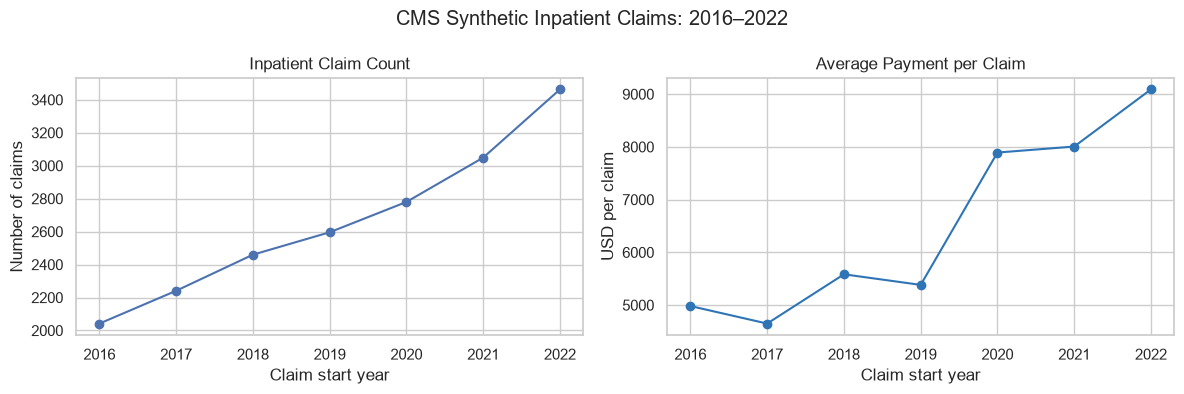

In [44]:
annual_comparison = annual_summary.loc[
    annual_summary["service_year"].between(2016, 2022)
].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    annual_comparison["service_year"],
    annual_comparison["claim_count"],
    marker="o",
)
axes[0].set_title("Inpatient Claim Count")
axes[0].set_ylabel("Number of claims")

axes[1].plot(
    annual_comparison["service_year"],
    annual_comparison["average_claim_payment"],
    marker="o",
    color="#2F75B5",
)
axes[1].set_title("Average Payment per Claim")
axes[1].set_ylabel("USD per claim")

for ax in axes:
    ax.set_xlabel("Claim start year")
    ax.set_xticks(annual_comparison["service_year"])

fig.suptitle("CMS Synthetic Inpatient Claims: 2016–2022")
plt.tight_layout()
plt.show()

In [46]:
utilization_summary = annual_comparison[
    [
        "service_year",
        "claim_count",
        "beneficiary_count",
        "total_claim_payment",
        "average_claim_payment",
    ]
].copy()

utilization_summary["claims_per_claimant"] = (
    utilization_summary["claim_count"]
    / utilization_summary["beneficiary_count"]
)

utilization_summary["payment_per_claimant"] = (
    utilization_summary["total_claim_payment"]
    / utilization_summary["beneficiary_count"]
)

display(utilization_summary.round(2))

,service_year,claim_count,beneficiary_count,total_claim_payment,average_claim_payment,claims_per_claimant,payment_per_claimant
1,2016,2042,1227,10172720.41,4981.74,1.66,8290.73
2,2017,2241,1270,10419522.27,4649.50,1.76,8204.35
3,2018,2460,1378,13735673.98,5583.61,1.79,9967.83
4,2019,2596,1419,13973961.86,5382.88,1.83,9847.75
5,2020,2780,1529,21941065.40,7892.47,1.82,14349.94
6,2021,3049,1617,24411096.07,8006.26,1.89,15096.53
7,2022,3463,1684,31479029.31,9090.10,2.06,18693.01


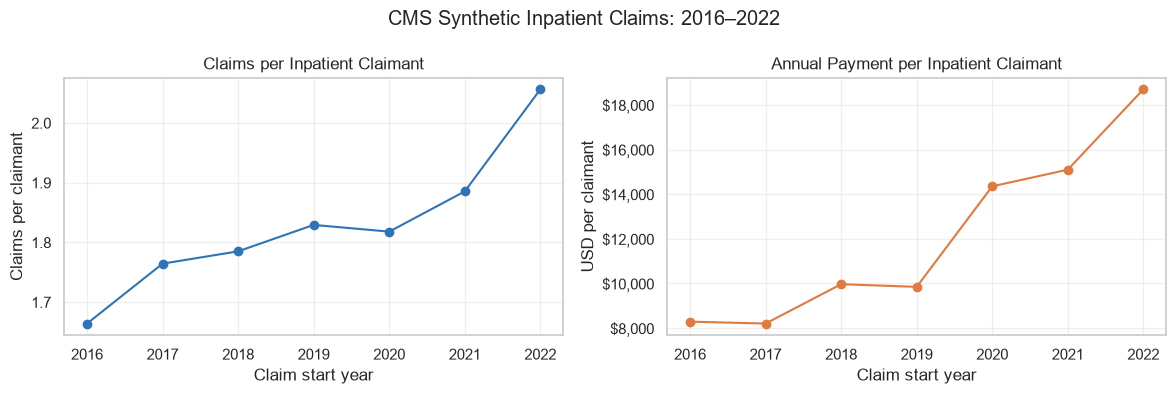

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

years = utilization_summary["service_year"]

axes[0].plot(
    years,
    utilization_summary["claims_per_claimant"],
    marker="o",
    color="#2F75B5",
)
axes[0].set_title("Claims per Inpatient Claimant")
axes[0].set_ylabel("Claims per claimant")

axes[1].plot(
    years,
    utilization_summary["payment_per_claimant"],
    marker="o",
    color="#E07A3F",
)
axes[1].set_title("Annual Payment per Inpatient Claimant")
axes[1].set_ylabel("USD per claimant")
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"${value:,.0f}")
)

for ax in axes:
    ax.set_xlabel("Claim start year")
    ax.set_xticks(years)
    ax.grid(True, alpha=0.3)

fig.suptitle("CMS Synthetic Inpatient Claims: 2016–2022")
plt.tight_layout()
plt.show()

In [48]:
payment_query = """
SELECT
    SERVICE_YEAR AS service_year,
    CLM_ID,
    CLM_PMT_AMT AS claim_payment
FROM inpatient_claim
WHERE SERVICE_YEAR BETWEEN 2016 AND 2022
"""

with sqlite3.connect(DATABASE_FILE) as connection:
    payment_data = pd.read_sql_query(
        payment_query,
        connection,
    )

payment_distribution = (
    payment_data
    .groupby("service_year")["claim_payment"]
    .agg(
        claim_count="size",
        mean_payment="mean",
        median_payment="median",
        p90_payment=lambda values: values.quantile(0.90),
        p99_payment=lambda values: values.quantile(0.99),
    )
    .reset_index()
)

display(payment_distribution.round(2))

,service_year,claim_count,mean_payment,median_payment,p90_payment,p99_payment
0,2016,2042,4981.74,1024.14,14709.58,50704.63
1,2017,2241,4649.50,1067.67,13641.73,49772.09
2,2018,2460,5583.61,1067.54,14614.25,64962.01
3,2019,2596,5382.88,1000.32,14308.76,54238.50
4,2020,2780,7892.47,1192.95,20892.40,97923.75
5,2021,3049,8006.26,1106.36,18727.35,109298.48
6,2022,3463,9090.10,1021.86,18295.53,124723.27


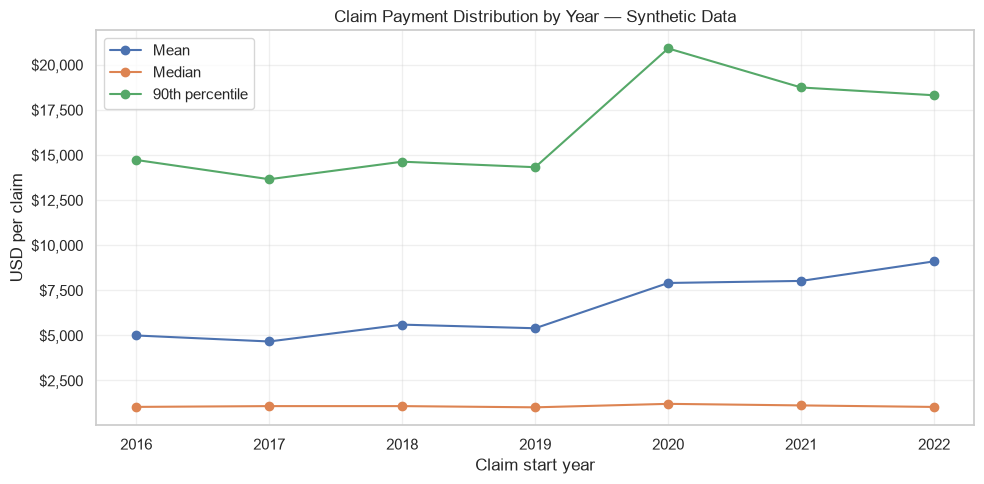

In [50]:
fig, ax = plt.subplots(figsize=(10, 5))

for column, label in [
    ("mean_payment", "Mean"),
    ("median_payment", "Median"),
    ("p90_payment", "90th percentile"),
]:
    ax.plot(
        payment_distribution["service_year"],
        payment_distribution[column],
        marker="o",
        label=label,
    )

ax.set_title("Claim Payment Distribution by Year — Synthetic Data")
ax.set_xlabel("Claim start year")
ax.set_ylabel("USD per claim")
ax.set_xticks(payment_distribution["service_year"])

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"${value:,.0f}")
)

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [51]:
import math

concentration_results = []

for year, group in payment_data.groupby("service_year"):
    amounts = (
        group["claim_payment"]
        .dropna()
        .sort_values(ascending=False)
    )

    total_payment = amounts.sum()

    for fraction in [0.01, 0.10]:
        top_n = math.ceil(len(amounts) * fraction)
        top_payment = amounts.head(top_n).sum()

        concentration_results.append({
            "service_year": year,
            "top_group": f"Top {fraction:.0%}",
            "selected_claims": top_n,
            "payment_share_percent": (
                top_payment / total_payment * 100
            ),
        })

concentration = pd.DataFrame(concentration_results)

display(concentration.round(2))

,service_year,top_group,selected_claims,payment_share_percent
0,2016,Top 1%,21,19.18
1,2016,Top 10%,205,60.33
2,2017,Top 1%,23,18.47
3,2017,Top 10%,225,60.43
4,2018,Top 1%,25,24.46
5,2018,Top 10%,246,63.18
6,2019,Top 1%,26,27.53
7,2019,Top 10%,260,66.61
8,2020,Top 1%,28,23.75
9,2020,Top 10%,278,65.42


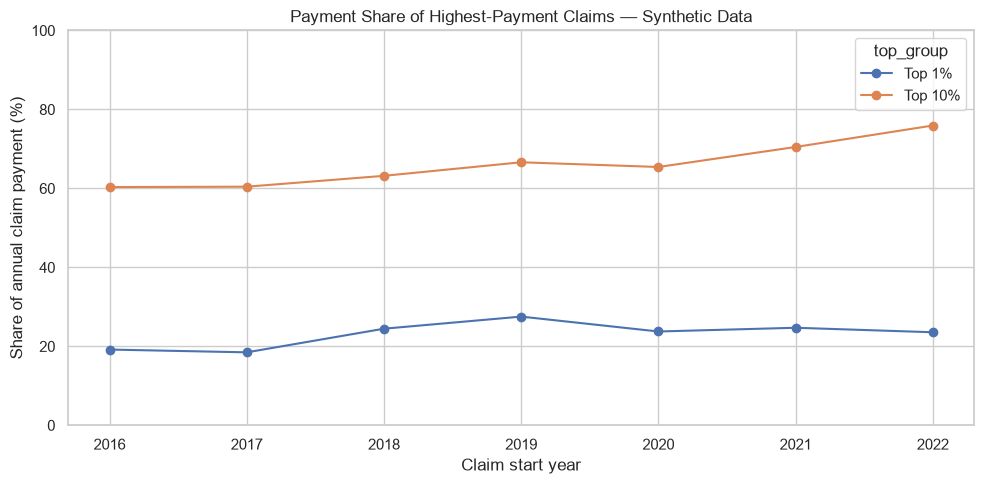

In [52]:
concentration_plot = concentration.pivot(
    index="service_year",
    columns="top_group",
    values="payment_share_percent",
)

ax = concentration_plot.plot(
    marker="o",
    figsize=(10, 5),
)

ax.set_title("Payment Share of Highest-Payment Claims — Synthetic Data")
ax.set_xlabel("Claim start year")
ax.set_ylabel("Share of annual claim payment (%)")
ax.set_xticks(concentration_plot.index)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

In [53]:
patient_year_query = """
SELECT
    SERVICE_YEAR AS service_year,
    BENE_ID AS beneficiary_id,
    COUNT(*) AS claim_count,
    SUM(CLM_PMT_AMT) AS annual_inpatient_payment
FROM inpatient_claim
WHERE SERVICE_YEAR BETWEEN 2016 AND 2022
GROUP BY SERVICE_YEAR, BENE_ID
ORDER BY SERVICE_YEAR, BENE_ID
"""

with sqlite3.connect(DATABASE_FILE) as connection:
    patient_year_payment = pd.read_sql_query(
        patient_year_query,
        connection,
    )

display(patient_year_payment.head(10))

display(
    patient_year_payment.groupby("service_year").agg(
        claimant_count=("beneficiary_id", "size"),
        total_claims=("claim_count", "sum"),
        total_payment=("annual_inpatient_payment", "sum"),
    ).round(2)
)

,service_year,beneficiary_id,claim_count,annual_inpatient_payment
0,2016,-10000010254711,1,96.65
1,2016,-10000010254734,3,4114.45
2,2016,-10000010254768,1,96.65
3,2016,-10000010254773,1,6443.47
4,2016,-10000010254776,1,96.65
5,2016,-10000010254785,1,4594.23
6,2016,-10000010254807,1,555.75
7,2016,-10000010254843,1,2574.99
8,2016,-10000010254852,2,1111.50
9,2016,-10000010254860,2,40746.09


,claimant_count,total_claims,total_payment
service_year,,,
2016,1227,2042,10172720.41
2017,1270,2241,10419522.27
2018,1378,2460,13735673.98
2019,1419,2596,13973961.86
2020,1529,2780,21941065.40
2021,1617,3049,24411096.07
2022,1684,3463,31479029.31


In [54]:
import math

patient_concentration_results = []

for year, group in patient_year_payment.groupby("service_year"):
    ranked_patients = group.sort_values(
        ["annual_inpatient_payment", "beneficiary_id"],
        ascending=[False, True],
    )

    total_payment = ranked_patients["annual_inpatient_payment"].sum()

    for fraction in [0.01, 0.10]:
        top_n = math.ceil(len(ranked_patients) * fraction)
        top_patients = ranked_patients.head(top_n)

        patient_concentration_results.append({
            "service_year": year,
            "top_group": f"Top {fraction:.0%}",
            "selected_patients": top_n,
            "payment_share_percent": (
                top_patients["annual_inpatient_payment"].sum()
                / total_payment * 100
            ),
            "average_claims_per_selected_patient": (
                top_patients["claim_count"].mean()
            ),
        })

patient_concentration = pd.DataFrame(
    patient_concentration_results
)

display(patient_concentration.round(2))

,service_year,top_group,selected_patients,payment_share_percent,average_claims_per_selected_patient
0,2016,Top 1%,13,16.15,3.15
1,2016,Top 10%,123,57.67,3.41
2,2017,Top 1%,13,15.59,3.77
3,2017,Top 10%,127,55.61,4.03
4,2018,Top 1%,14,21.15,3.57
5,2018,Top 10%,138,58.80,4.35
6,2019,Top 1%,15,23.48,2.47
7,2019,Top 10%,142,61.68,4.24
8,2020,Top 1%,16,28.62,5.06
9,2020,Top 10%,153,61.36,3.71


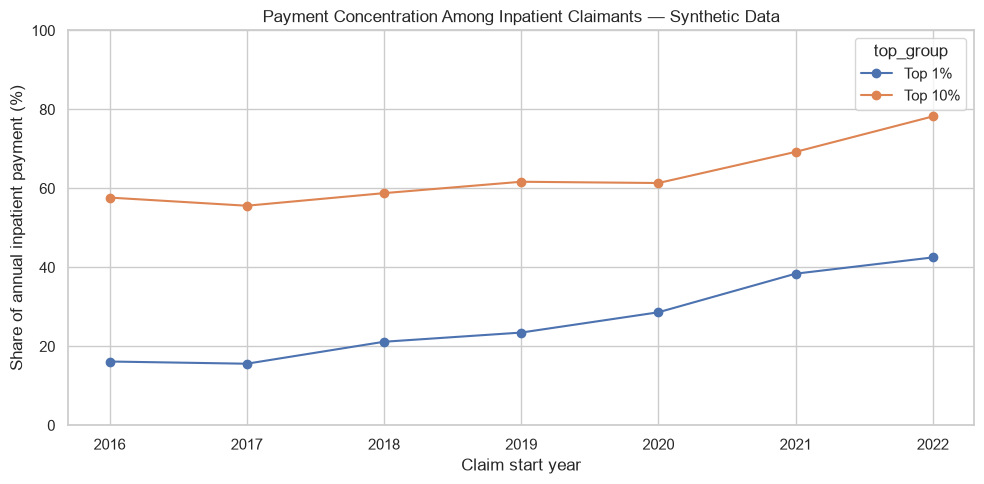

In [55]:
patient_concentration_plot = patient_concentration.pivot(
    index="service_year",
    columns="top_group",
    values="payment_share_percent",
)

ax = patient_concentration_plot.plot(
    marker="o",
    figsize=(10, 5),
)

ax.set_title(
    "Payment Concentration Among Inpatient Claimants — Synthetic Data"
)
ax.set_xlabel("Claim start year")
ax.set_ylabel("Share of annual inpatient payment (%)")
ax.set_xticks(patient_concentration_plot.index)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

In [56]:
patients_2022 = (
    patient_year_payment.loc[
        patient_year_payment["service_year"].eq(2022)
    ]
    .sort_values(
        ["annual_inpatient_payment", "beneficiary_id"],
        ascending=[False, True],
    )
    .copy()
)

top_n = math.ceil(len(patients_2022) * 0.01)

patients_2022["patient_group"] = "Remaining patients"
patients_2022.loc[
    patients_2022.head(top_n).index,
    "patient_group",
] = "Top 1%"

group_comparison = (
    patients_2022.groupby("patient_group")
    .agg(
        patient_count=("beneficiary_id", "size"),
        total_claims=("claim_count", "sum"),
        total_payment=("annual_inpatient_payment", "sum"),
    )
)

group_comparison["claims_per_patient"] = (
    group_comparison["total_claims"]
    / group_comparison["patient_count"]
)

group_comparison["payment_per_claim"] = (
    group_comparison["total_payment"]
    / group_comparison["total_claims"]
)

group_comparison["payment_per_patient"] = (
    group_comparison["total_payment"]
    / group_comparison["patient_count"]
)

display(group_comparison.round(2))

,patient_count,total_claims,total_payment,claims_per_patient,payment_per_claim,payment_per_patient
patient_group,,,,,,
Remaining patients,1667,3323,18095191.87,1.99,5445.44,10854.94
Top 1%,17,140,13383837.44,8.24,95598.84,787284.56


In [57]:
patients_2022 = (
    patient_year_payment.loc[
        patient_year_payment["service_year"].eq(2022)
    ]
    .sort_values(
        ["annual_inpatient_payment", "beneficiary_id"],
        ascending=[False, True],
    )
    .copy()
)

top_n = math.ceil(len(patients_2022) * 0.01)

patients_2022["patient_group"] = "Remaining patients"
patients_2022.loc[
    patients_2022.head(top_n).index,
    "patient_group",
] = "Top 1%"

group_comparison = (
    patients_2022.groupby("patient_group")
    .agg(
        patient_count=("beneficiary_id", "size"),
        total_claims=("claim_count", "sum"),
        total_payment=("annual_inpatient_payment", "sum"),
    )
)

group_comparison["claims_per_patient"] = (
    group_comparison["total_claims"]
    / group_comparison["patient_count"]
)

group_comparison["payment_per_claim"] = (
    group_comparison["total_payment"]
    / group_comparison["total_claims"]
)

group_comparison["payment_per_patient"] = (
    group_comparison["total_payment"]
    / group_comparison["patient_count"]
)

display(group_comparison.round(2))

,patient_count,total_claims,total_payment,claims_per_patient,payment_per_claim,payment_per_patient
patient_group,,,,,,
Remaining patients,1667,3323,18095191.87,1.99,5445.44,10854.94
Top 1%,17,140,13383837.44,8.24,95598.84,787284.56


In [58]:
top_patient_ids = patients_2022.loc[
    patients_2022["patient_group"].eq("Top 1%"),
    "beneficiary_id",
]

top_claims_2022 = inpatient_claim.loc[
    inpatient_claim["SERVICE_YEAR"].eq(2022)
    & inpatient_claim["BENE_ID"].isin(top_patient_ids)
].copy()

top_patient_detail = (
    top_claims_2022.groupby("BENE_ID")
    .agg(
        claim_count=("CLM_ID", "size"),
        annual_payment=("CLM_PMT_AMT", "sum"),
        mean_claim_payment=("CLM_PMT_AMT", "mean"),
        median_claim_payment=("CLM_PMT_AMT", "median"),
        max_claim_payment=("CLM_PMT_AMT", "max"),
    )
    .sort_values("annual_payment", ascending=False)
)

top_patient_detail["largest_claim_share_percent"] = (
    top_patient_detail["max_claim_payment"]
    / top_patient_detail["annual_payment"]
    * 100
)

display(top_patient_detail.round(2))

print("Patients:", len(top_patient_detail))
print("Claims:", top_patient_detail["claim_count"].sum())

,claim_count,annual_payment,mean_claim_payment,median_claim_payment,max_claim_payment,largest_claim_share_percent
BENE_ID,,,,,,
-10000010271384,11,1031007.84,93727.99,91911.4,246764.71,23.93
-10000010265392,10,982238.99,98223.9,74135.08,275770.14,28.08
-10000010259295,10,977723.61,97772.36,93699.3,153161.49,15.67
-10000010258483,9,961260.3,106806.7,87006.14,282127.66,29.35
-10000010264641,9,930515.93,103390.66,74025.44,212333.83,22.82
-10000010258819,9,924824.49,102758.28,85939.39,235621.9,25.48
-10000010260059,10,897625.27,89762.53,89254.78,134359.8,14.97
-10000010280747,10,874837.18,87483.72,77290.3,170313.92,19.47
-10000010280870,9,852330.06,94703.34,59996.03,240907.47,28.26


Patients: 17
Claims: 140


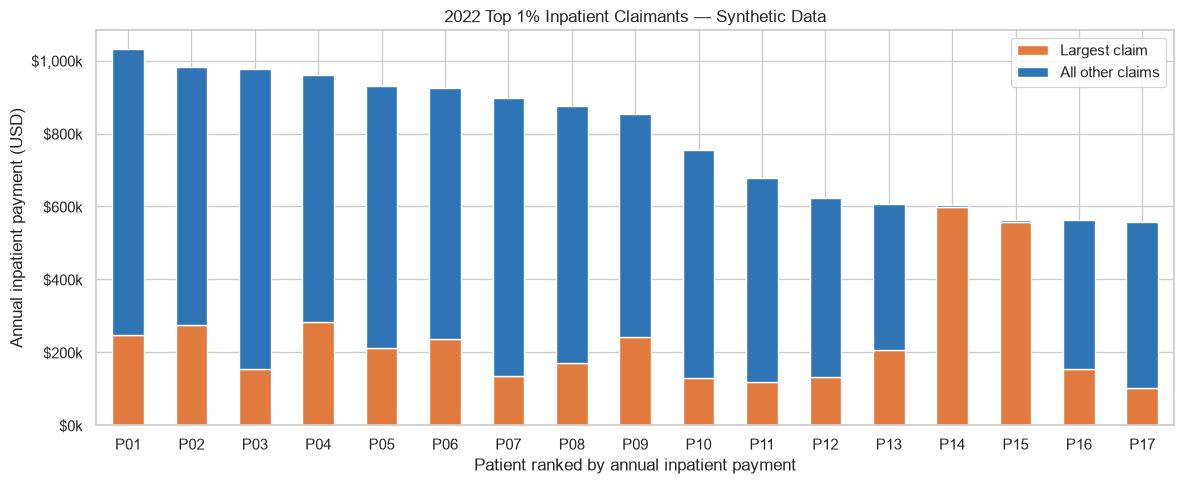

In [59]:
patient_plot = top_patient_detail.copy()

# 按年度金额排名，用简短标签代替长患者 ID
patient_plot["patient_label"] = [
    f"P{i:02d}" for i in range(1, len(patient_plot) + 1)
]

patient_plot["other_claims_payment"] = (
    patient_plot["annual_payment"]
    - patient_plot["max_claim_payment"]
)

ax = patient_plot.set_index("patient_label")[
    ["max_claim_payment", "other_claims_payment"]
].plot(
    kind="bar",
    stacked=True,
    figsize=(12, 5),
    color=["#E07A3F", "#2F75B5"],
)

ax.set_title("2022 Top 1% Inpatient Claimants — Synthetic Data")
ax.set_xlabel("Patient ranked by annual inpatient payment")
ax.set_ylabel("Annual inpatient payment (USD)")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"${value / 1000:,.0f}k")
)

ax.legend(["Largest claim", "All other claims"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [60]:
timeline = top_claims_2022[
    [
        "BENE_ID",
        "CLM_ID",
        "PRVDR_NUM",
        "CLM_ADMSN_DT",
        "NCH_BENE_DSCHRG_DT",
        "CLM_PMT_AMT",
    ]
].copy()

# 本次时间检查需要完整、顺序正确的日期
valid_dates = (
    timeline["CLM_ADMSN_DT"].notna()
    & timeline["NCH_BENE_DSCHRG_DT"].notna()
    & timeline["NCH_BENE_DSCHRG_DT"].ge(
        timeline["CLM_ADMSN_DT"]
    )
)

print("Claims excluded from date check:", (~valid_dates).sum())

timeline = (
    timeline.loc[valid_dates]
    .sort_values(
        [
            "BENE_ID",
            "CLM_ADMSN_DT",
            "NCH_BENE_DSCHRG_DT",
            "CLM_ID",
        ]
    )
    .reset_index(drop=True)
)

timeline["prior_latest_discharge"] = (
    timeline.groupby("BENE_ID")["NCH_BENE_DSCHRG_DT"]
    .transform(lambda dates: dates.cummax().shift(1))
)

timeline["gap_days"] = (
    timeline["CLM_ADMSN_DT"]
    - timeline["prior_latest_discharge"]
).dt.days.astype("Int64")

timeline["date_relationship"] = "First claim"

has_prior = timeline["prior_latest_discharge"].notna()

timeline.loc[
    has_prior & timeline["gap_days"].lt(0),
    "date_relationship",
] = "Overlapping dates"

timeline.loc[
    has_prior & timeline["gap_days"].eq(0),
    "date_relationship",
] = "Same-day boundary"

timeline.loc[
    has_prior & timeline["gap_days"].gt(0),
    "date_relationship",
] = "Separated dates"

display(
    timeline["date_relationship"]
    .value_counts()
    .to_frame("claim_count")
)

Claims excluded from date check: 0


,claim_count
date_relationship,
Separated dates,120
First claim,17
Overlapping dates,3


In [61]:
overlap_pairs = []

overlap_rows = timeline.loc[
    timeline["date_relationship"].eq("Overlapping dates")
]

for current_index, current in overlap_rows.iterrows():
    prior_claims = timeline.loc[
        timeline.index.to_series().lt(current_index)
        & timeline["BENE_ID"].eq(current["BENE_ID"])
        & timeline["NCH_BENE_DSCHRG_DT"].gt(
            current["CLM_ADMSN_DT"]
        )
    ]

    for _, prior in prior_claims.iterrows():
        overlap_pairs.append({
            "BENE_ID": current["BENE_ID"],
            "prior_claim_id": prior["CLM_ID"],
            "current_claim_id": current["CLM_ID"],
            "prior_admission": prior["CLM_ADMSN_DT"],
            "prior_discharge": prior["NCH_BENE_DSCHRG_DT"],
            "current_admission": current["CLM_ADMSN_DT"],
            "current_discharge": current["NCH_BENE_DSCHRG_DT"],
            "same_provider": (
                prior["PRVDR_NUM"] == current["PRVDR_NUM"]
            ),
            "prior_payment": prior["CLM_PMT_AMT"],
            "current_payment": current["CLM_PMT_AMT"],
        })

overlap_pair_detail = pd.DataFrame(overlap_pairs)

display(overlap_pair_detail)

,BENE_ID,prior_claim_id,current_claim_id,prior_admission,prior_discharge,current_admission,current_discharge,same_provider,prior_payment,current_payment
0,-10000010273157,-10000930859068,-10000930859069,2022-03-20,2022-03-21,2022-03-20,2022-03-23,<NA>,2743.75,557821.86
1,-10000010273157,-10000930859069,-10000930859070,2022-03-20,2022-03-23,2022-03-22,2022-03-23,<NA>,557821.86,1276.11
2,-10000010275180,-10000930956747,-10000930956748,2022-12-28,2022-12-29,2022-12-28,2023-01-02,<NA>,2763.87,598716.31


In [62]:
overlap_claim_ids = pd.unique(
    overlap_pair_detail[
        ["prior_claim_id", "current_claim_id"]
    ].to_numpy().ravel()
)

review_columns = [
    "BENE_ID",
    "PRVDR_NUM",
    "ORG_NPI_NUM",
    "CLM_ADMSN_DT",
    "NCH_BENE_DSCHRG_DT",
    "CLM_FROM_DT",
    "CLM_THRU_DT",
    "CLM_PMT_AMT",
    "CLM_FREQ_CD",
    "FI_CLM_ACTN_CD",
    "CLAIM_QUERY_CODE",
    "CLM_DRG_CD",
    "PRNCPAL_DGNS_CD",
]

overlap_claim_review = (
    inpatient_claim.loc[
        inpatient_claim["CLM_ID"].isin(overlap_claim_ids)
    ]
    .sort_values(["BENE_ID", "CLM_ADMSN_DT", "CLM_ID"])
    .set_index("CLM_ID")[review_columns]
)

display(overlap_claim_review.T)

CLM_ID,-10000930859068,-10000930859069,-10000930859070,-10000930956747,-10000930956748
BENE_ID,-10000010273157,-10000010273157,-10000010273157,-10000010275180,-10000010275180
PRVDR_NUM,<NA>,<NA>,<NA>,<NA>,<NA>
ORG_NPI_NUM,1871064949,1871064949,1871064949,1700134160,1700134160
CLM_ADMSN_DT,2022-03-20 00:00:00,2022-03-20 00:00:00,2022-03-22 00:00:00,2022-12-28 00:00:00,2022-12-28 00:00:00
NCH_BENE_DSCHRG_DT,2022-03-21 00:00:00,2022-03-23 00:00:00,2022-03-23 00:00:00,2022-12-29 00:00:00,2023-01-02 00:00:00
CLM_FROM_DT,2022-03-20 00:00:00,2022-03-20 00:00:00,2022-03-22 00:00:00,2022-12-28 00:00:00,2022-12-28 00:00:00
CLM_THRU_DT,2022-03-21 00:00:00,2022-03-23 00:00:00,2022-03-23 00:00:00,2022-12-29 00:00:00,2023-01-02 00:00:00
CLM_PMT_AMT,2743.75,557821.86,1276.11,2763.87,598716.31
CLM_FREQ_CD,1,1,1,1,1
FI_CLM_ACTN_CD,<NA>,<NA>,<NA>,<NA>,<NA>


## Overlapping claims among 2022 top-payment claimants

Among 140 claims from the 17 highest-payment claimants,
three overlapping claim pairs involve five distinct claims
from two beneficiaries.

Within each beneficiary, the overlapping claims share an
organization NPI but differ in dates, amounts, or diagnosis-related
attributes. Their relationship remains unresolved.

All claims and payment amounts are retained.
Claim counts are not interpreted as independent hospitalization counts.

In [63]:
REPORT_DIR = PROJECT_ROOT / "reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

analysis_outputs = {
    "inpatient_annual_summary": annual_summary,
    "inpatient_year_coverage": year_coverage,
    "inpatient_payment_distribution": payment_distribution,
    "inpatient_claim_concentration": concentration,
    "inpatient_patient_concentration": patient_concentration,
    "inpatient_2022_top_patient_detail": (
        top_patient_detail.reset_index()
    ),
    "inpatient_2022_overlap_pairs": overlap_pair_detail,
}

for name, result in analysis_outputs.items():
    result.to_csv(
        REPORT_DIR / f"{name}.csv",
        index=False,
        date_format="%Y-%m-%d",
    )

print(f"Saved {len(analysis_outputs)} analysis reports.")

Saved 7 analysis reports.
